In [88]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [89]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

--2025-10-12 16:35:00--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.1’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.03s   

2025-10-12 16:35:00 (2.81 MB/s) - ‘course_lead_scoring.csv.1’ saved [80876/80876]



In [90]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [91]:
# Check for missing values
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [92]:
cat_cols = list(df.select_dtypes(include=['object']).columns)
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)

df[cat_cols] = df[cat_cols].fillna('NA')
df[num_cols] = df[num_cols].fillna(0)

In [93]:
# Check for missing values again
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [94]:
df.industry.mode()[0]

'retail'

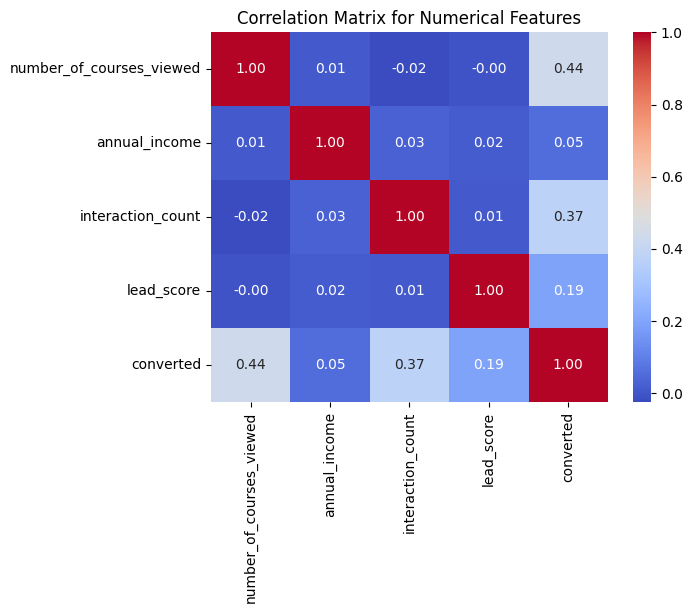

In [95]:
# Create correlation matrix for numerical features
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix for Numerical Features')
plt.show()

In [96]:
# Train-val-test split
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)

len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [97]:
# Reset index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [98]:
# Remove target from features
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_test = df_test['converted'].values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [99]:
# Calculate mutual information between each feature and the target
from sklearn.metrics import mutual_info_score

def calculate_mi(series):
    return round(mutual_info_score(series, y_train), 2)

mi_scores = df_train[cat_cols].apply(calculate_mi)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

lead_source          0.04
industry             0.01
employment_status    0.01
location             0.00
dtype: float64

In [100]:
# One-hot encoding for categorical features
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)

train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

test_dicts = df_test.to_dict(orient='records')
X_test = dv.transform(test_dicts)

In [101]:
# Fit a logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [102]:
# Calculate accuracy on the validation set
from sklearn.metrics import accuracy_score
y_val_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_val_pred)
accuracy

0.6996587030716723

In [103]:
first_model_accuracy = accuracy

In [104]:
# Train models where one feature from the dataframe is removed
features = df_train.columns.tolist()
results = np.zeros(len(features))
for i, feature in enumerate(features):
    selected_features = [f for f in features if f != feature]
    
    train_dicts = df_train[selected_features].to_dict(orient='records')
    X_train = dv.fit_transform(train_dicts)
    
    val_dicts = df_val[selected_features].to_dict(orient='records')
    X_val = dv.transform(val_dicts)
    
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    results[i] = accuracy
    print(f'Feature removed: {feature}, Accuracy: {accuracy}')

results_df = pd.DataFrame({'feature': features, 'accuracy': results})
results_df["accuracy_diff"] = np.abs(results_df["accuracy"] - first_model_accuracy)
results_df = results_df.sort_values(by='accuracy_diff', ascending=True)
results_df

Feature removed: lead_source, Accuracy: 0.7030716723549488
Feature removed: industry, Accuracy: 0.6996587030716723
Feature removed: number_of_courses_viewed, Accuracy: 0.5563139931740614
Feature removed: annual_income, Accuracy: 0.8532423208191127
Feature removed: employment_status, Accuracy: 0.6962457337883959
Feature removed: location, Accuracy: 0.7098976109215017
Feature removed: interaction_count, Accuracy: 0.5563139931740614
Feature removed: lead_score, Accuracy: 0.7064846416382252


,feature,accuracy,accuracy_diff
1,industry,0.699659,0.000000
4,employment_status,0.696246,0.003413
0,lead_source,0.703072,0.003413
7,lead_score,0.706485,0.006826
5,location,0.709898,0.010239
2,number_of_courses_viewed,0.556314,0.143345
6,interaction_count,0.556314,0.143345
3,annual_income,0.853242,0.153584


In [105]:
# Prepare dataset for final model
train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

test_dicts = df_test.to_dict(orient='records')
X_test = dv.transform(test_dicts)

In [106]:
# Train regularized models
C = [0.01, 0.1, 1, 10, 100, 1000]
scores = []
for c in C:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_val)
    accuracy = round(accuracy_score(y_val, y_val_pred), 2)
    scores.append(accuracy)
    print(f'C: {c}, Accuracy: {accuracy}')

C: 0.01, Accuracy: 0.7
C: 0.1, Accuracy: 0.7
C: 1, Accuracy: 0.7
C: 10, Accuracy: 0.7
C: 100, Accuracy: 0.7
C: 1000, Accuracy: 0.7
